##  Этап 0: Импорт библиотек

In [1]:
# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from collections import Counter

from sklearn.linear_model import (
    LinearRegression, Ridge, Lasso, ElasticNet,
    LinearRegression as SklearnLinearRegression
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

## Этап 1: Ответы на теоретические вопросы 

## 1. Теоретические вопросы по линейной регрессии

### 1.a) Аналитическое решение (нормальное уравнение)

Для линейной регрессии существует аналитическое решение, позволяющее найти оптимальные параметры модели напрямую:

$$ \hat{\theta} = (X^T X)^{-1} X^T y $$

**Обозначения:**
- $X$ — матрица признаков размерности $N \times D$
- $y$ — вектор целевых значений размерности $N \times 1$
- $\hat{\theta}$ — оптимальные параметры модели размерности $D \times 1$

> !!! **Важно:** Вычисление $(X^T X)^{-1}$ может быть вычислительно затратным при большом количестве признаков $D$, особенно при $D > 10^4$.

---

### 1.b) Регуляризация в линейной регрессии

Добавление регуляризации в функцию потерь позволяет контролировать сложность модели:

$$ \min_{\theta} \left[ \frac{1}{N} \sum_{i=1}^{N} L(f(x_i, \theta), y_i) + \lambda \cdot R(\theta) \right] $$

**Где:**
- $L(\cdot)$ — основная функция потерь (например, MSE - среднеквадратичная ошибка)
- $R(\theta)$ — штраф за сложность модели (регуляризационный член)
- $\lambda$ — гиперпараметр регуляризации, контролирующий силу штрафа

**Цель регуляризации:**
- Предотвратить переобучение модели
- Ограничить рост весов коэффициентов
- Улучшить обобщающую способность модели

---

### 1.c) Почему L1-регуляризация (Lasso) используется для отбора признаков

**L1-регуляризация (Lasso)** обладает уникальным свойством разреженности решений:

$$ R(\theta) = \sum_{i=1}^{D} |\theta_i| $$

**Причины эффективности для отбора признаков:**

1. **Геометрическая интерпретация:**
   - L1-штраф формирует область ограничений в форме **ромба** с острыми углами
   - При оптимизации решение часто попадает точно на угол ромба

2. **Математическое свойство:**
   - В угловых точках некоторые координаты равны нулю
   - Это приводит к обнулению весов слабых признаков

3. **Результат:**
   - Слабые признаки получают нулевые коэффициенты
   - Модель становится **разреженной** (sparse solution)
   - Происходит **автоматический отбор наиболее важных признаков** 

4. **Сравнение с L2-регуляризацией (Ridge):**
   - L2-регуляризация $R(\theta) = \sum \theta_i^2$ дает круглую область ограничений
   - Решение редко попадает точно на оси, поэтому веса уменьшаются, но редко обнуляются

---

### 1.d) Создание нелинейных признаков для линейной модели

Линейные модели можно использовать для аппроксимации нелинейных зависимостей путем создания новых признаков:

#### Методы создания нелинейных признаков:

1. **Полиномиальные признаки:**
   $$ x_1^2, x_2^2, x_1^3, x_2^3, \ldots $$

2. **Тригонометрические признаки:**
   $$ \sin(x_1), \cos(x_1), \sin(x_2), \cos(x_2), \ldots $$

3. **Взаимодействия признаков:**
   $$ x_1 \times x_2, \frac{x_1}{x_2}, x_1 \cdot x_3, \ldots $$

4. **Логарифмические и экспоненциальные преобразования:**
   $$ \log(x_1), e^{x_1}, \sqrt{x_1}, \ldots $$

#### Важное замечание:

> **Ключевое преимущество:** Модель остается **линейной по параметрам** $\theta$, но становится **нелинейной по исходным признакам** $x$ 

Это позволяет:
- Сохранить вычислительную эффективность линейных моделей
- Моделировать сложные нелинейные зависимости
- Использовать преимущества регуляризации

---

### 1.e) Выбор гиперпараметров регуляризации

Для выбора оптимального значения $\lambda$ в регуляризованных моделях используются следующие подходы:

1. **Cross-Validation (Кросс-валидация):**
   - Разбиение данных на обучающую и валидационную выборки
   - Поиск $\lambda$, минимизирующего ошибку на валидации

2. **Grid Search (Сеточный поиск):**
   - Перебор по сетке возможных значений $\lambda$
   - Выбор наилучшего по метрикам качества

3. **Random Search (Случайный поиск):**
   - Более эффективен при большом количестве гиперпараметров

4. **Information Criteria:**
   - AIC (Akaike Information Criterion)
   - BIC (Bayesian Information Criterion)

---

### 1.f) Метрики качества регрессионных моделей

#### Основные метрики:

| Метрика | Формула | Интерпретация |
|---------|---------|---------------|
| **MAE** (Mean Absolute Error) | $\frac{1}{N}\sum_{i=1}^{N} \|y_i - \hat{y}_i\|$ | Средняя абсолютная ошибка |
| **MSE** (Mean Squared Error) | $\frac{1}{N}\sum_{i=1}^{N} (y_i - \hat{y}_i)^2$ | Среднеквадратичная ошибка |
| **RMSE** (Root MSE) | $\sqrt{\text{MSE}}$ | Корень из MSE (в единицах целевой переменной) |
| **R²** (Coefficient of Determination) | $1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$ | Доля объясненной дисперсии |

#### Интерпретация R²:
- $R^2 = 1$ — идеальное предсказание
- $R^2 = 0$ — модель не лучше среднего
- $R^2 < 0$ — модель хуже, чем предсказание средним значением

---

### Резюме

- **Нормальное уравнение** дает аналитическое решение, но требует обращения матрицы
- **Регуляризация** помогает бороться с переобучением
- **L1-регуляризация** обеспечивает отбор признаков
- **Нелинейные признаки** расширяют возможности линейных моделей
- **Кросс-валидация** помогает выбрать оптимальные гиперпараметры
- **Метрики качества** позволяют объективно сравнивать модели

## Этап 2: Предобработка данных

### 2.1. Загрузка и анализ исходных датафреймов

In [2]:
# Настройки отображения
pd.set_option('display.max_columns', 50)
plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Загрузка данных
pd_train = pd.read_json('data/train.json')
pd_test = pd.read_json('data/test.json')

# Первичная информация
print("Train dataset info:")
print(pd_train.info())
print("\nTest dataset info:")
print(pd_test.info())

# Примеры колонки features
print("\nПримеры из колонки 'features':")
for i in range(5):
    print(f"{i+1}. {pd_train['features'].iloc[i]}")
print(f"\nТип данных: {type(pd_train['features'].iloc[0])}")

Train dataset info:
<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB
None

Test dataset info:
<class 'p

### 2.2. Обработка текстовых признаков (features)

In [4]:
# Функция нормализации названий признаков
def normalize_features(feature_list):
    """
    Преобразует ['Dining Room', 'laundry in building'] 
    в ['DiningRoom', 'LaundryInBuilding']
    """
    if not isinstance(feature_list, list):
        return []
    normalized = []
    for f in feature_list:
        f_clean = f.replace(' ', '').title()
        normalized.append(f_clean)
    return normalized

# Применяем нормализацию
pd_train['features_norm'] = pd_train['features'].apply(normalize_features)
pd_test['features_norm'] = pd_test['features'].apply(normalize_features)

# Сбор всех признаков для анализа частоты
all_features = []
for features_list in pd_train['features_norm']:
    all_features.extend(features_list)

print(f"Всего упоминаний признаков: {len(all_features)}")
print(f"Уникальных признаков (до очистки): {len(set(all_features))}")

# Топ-20 признаков через Counter
feature_counter = Counter(all_features)
top_20 = feature_counter.most_common(20)

print("\nТоп-20 самых популярных признаков (после нормализации):")
for rank, (feature, count) in enumerate(top_20, 1):
    print(f"{rank:2d}. {feature:25s} -> {count}")

# Динамическое извлечение TOP_20_FEATURES (без жёсткого кодирования)
TOP_20_FEATURES = [feature for feature, count in top_20]

# Проверка и удаление дубликатов (регистронезависимая)
features_lower = [f.lower() for f in TOP_20_FEATURES]
if len(features_lower) != len(set(features_lower)):
    print(f"\nНайдены дубликаты, удаляем...")
    seen = set()
    unique_features = []
    for f in TOP_20_FEATURES:
        f_lower = f.lower()
        if f_lower not in seen:
            seen.add(f_lower)
            unique_features.append(f)
    TOP_20_FEATURES = unique_features

print(f"\nИтоговое количество признаков: {len(TOP_20_FEATURES)}")

# Функция создания бинарных признаков
def create_binary_features(df, feature_col, top_features):
    """Создаёт бинарные колонки 0/1 для каждого признака"""
    df_copy = df.copy()
    for feature in top_features:
        df_copy[f'feat_{feature}'] = df_copy[feature_col].apply(
            lambda x: 1 if feature in x else 0
        )
    return df_copy

# Создаём бинарные признаки
print("\nСоздаём бинарные признаки...")
pd_train = create_binary_features(pd_train, 'features_norm', TOP_20_FEATURES)
pd_test = create_binary_features(pd_test, 'features_norm', TOP_20_FEATURES)
print(f"Добавлено {len(TOP_20_FEATURES)} новых колонок")

Всего упоминаний признаков: 267906
Уникальных признаков (до очистки): 1277

Топ-20 самых популярных признаков (после нормализации):
 1. Elevator                  -> 26273
 2. Hardwoodfloors            -> 23559
 3. Catsallowed               -> 23540
 4. Dogsallowed               -> 22035
 5. Doorman                   -> 20967
 6. Dishwasher                -> 20808
 7. Laundryinbuilding         -> 18944
 8. Nofee                     -> 18079
 9. Fitnesscenter             -> 13257
10. Laundryinunit             -> 9435
11. Pre-War                   -> 9149
12. Roofdeck                  -> 6613
13. Outdoorspace              -> 5270
14. Diningroom                -> 5150
15. Highspeedinternet         -> 4299
16. Balcony                   -> 3058
17. Swimmingpool              -> 2730
18. Newconstruction           -> 2608
19. Terrace                   -> 2313
20. Exclusive                 -> 2167

Итоговое количество признаков: 20

Создаём бинарные признаки...
Добавлено 20 новых колонок


### 2.3. Подготовка признаков и целевой переменной

In [5]:
# Итоговый список признаков: 2 базовых + 20 бинарных = 22 признака
BASE_FEATURES = ['bathrooms', 'bedrooms']
FEATURE_LIST = BASE_FEATURES + [f'feat_{f}' for f in TOP_20_FEATURES]

print(f"FEATURE_LIST ({len(FEATURE_LIST)} признаков):")
for i, f in enumerate(FEATURE_LIST, 1):
    print(f"{i:2d}. {f}")

# Формируем матрицы признаков и целевую переменную
X_train = pd_train[FEATURE_LIST].copy()
y_train = pd_train['price'].copy()
X_test = pd_test[FEATURE_LIST].copy()

print(f"\nX_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}")

# Сохраняем список признаков
joblib.dump(FEATURE_LIST, 'data/feature_list.pkl')
print("FEATURE_LIST сохранён в data/feature_list.pkl")

# Статистика по целевой переменной
print(f"\nСтатистика по целевой переменной 'price':")
print(y_train.describe())

FEATURE_LIST (22 признаков):
 1. bathrooms
 2. bedrooms
 3. feat_Elevator
 4. feat_Hardwoodfloors
 5. feat_Catsallowed
 6. feat_Dogsallowed
 7. feat_Doorman
 8. feat_Dishwasher
 9. feat_Laundryinbuilding
10. feat_Nofee
11. feat_Fitnesscenter
12. feat_Laundryinunit
13. feat_Pre-War
14. feat_Roofdeck
15. feat_Outdoorspace
16. feat_Diningroom
17. feat_Highspeedinternet
18. feat_Balcony
19. feat_Swimmingpool
20. feat_Newconstruction
21. feat_Terrace
22. feat_Exclusive

X_train: (49352, 22)
y_train: (49352,)
X_test: (74659, 22)
FEATURE_LIST сохранён в data/feature_list.pkl

Статистика по целевой переменной 'price':
count    4.935200e+04
mean     3.830174e+03
std      2.206687e+04
min      4.300000e+01
25%      2.500000e+03
50%      3.150000e+03
75%      4.100000e+03
max      4.490000e+06
Name: price, dtype: float64


### 2.4. Удаление выбросов по процентилям

In [6]:
# Удаление выбросов в price по 1 и 99 процентилям (требование задания)
print("Удаление выбросов в целевой переменной price...")

# Находим перцентили
Q1 = y_train.quantile(0.01)
Q99 = y_train.quantile(0.99)

print(f"1-й перцентиль: ${Q1:,.2f}")
print(f"99-й перцентиль: ${Q99:,.2f}")
print(f"Исходный диапазон: ${y_train.min():,.2f} - ${y_train.max():,.2f}")

# Фильтруем данные
mask = (y_train >= Q1) & (y_train <= Q99)
y_train_filtered = y_train[mask].copy()
X_train_filtered = X_train[mask].copy()

print(f"Удалено выбросов: {(~mask).sum()} ({(~mask).mean()*100:.2f}%)")
print(f"Осталось записей: {mask.sum()}")

# Проверяем новую статистику
print(f"\nПосле фильтрации:")
print(f"Новый диапазон: ${y_train_filtered.min():,.2f} - ${y_train_filtered.max():,.2f}")
print(f"Новый mean: ${y_train_filtered.mean():,.2f}")
print(f"Новый std: ${y_train_filtered.std():,.2f}")

# Обновляем данные для дальнейшего использования
X_train = X_train_filtered
y_train = y_train_filtered

Удаление выбросов в целевой переменной price...
1-й перцентиль: $1,475.00
99-й перцентиль: $13,000.00
Исходный диапазон: $43.00 - $4,490,000.00
Удалено выбросов: 973 (1.97%)
Осталось записей: 48379

После фильтрации:
Новый диапазон: $1,475.00 - $13,000.00
Новый mean: $3,538.64
Новый std: $1,597.66


### 2.5. Разделение на train/validation

In [7]:
# Конвертация в numpy массивы
X_train_np = X_train.values
y_train_np = y_train.values
X_test_np = X_test.values

# Разделение на train (80%) и validation (20%)
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_np, y_train_np, 
    test_size=0.2, 
    random_state=42
)

print(f"Train set: {X_tr.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

Train set: 38703 samples
Validation set: 9676 samples


## Этап 3: Реализация линейной регрессии "с нуля" 

### 3.1. Реализация класса LinearRegressionSGD

In [8]:
# Класс линейной регрессии с градиентным спуском
class LinearRegressionSGD:
    """Линейная регрессия с использованием стохастического градиентного спуска"""
    
    def __init__(self, lr=0.01, n_epochs=100, batch_size=32, seed=42, verbose=True):
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.seed = seed
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.loss_history = []
        
    def _initialize_parameters(self, n_features):
        np.random.seed(self.seed)
        self.weights = np.random.randn(n_features) * 0.01
        self.bias = 0.0
        
    def _compute_mse(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)
    
    def _compute_gradient(self, X_batch, y_batch, y_pred):
        n_samples = len(y_batch)
        error = y_pred - y_batch
        dw = (2 / n_samples) * np.dot(X_batch.T, error)
        db = (2 / n_samples) * np.sum(error)
        return dw, db
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).flatten()
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        
        np.random.seed(self.seed)
        indices = np.arange(n_samples)
        
        for epoch in range(self.n_epochs):
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_shuffled = y[indices]
            
            for start_idx in range(0, n_samples, self.batch_size):
                end_idx = min(start_idx + self.batch_size, n_samples)
                X_batch = X_shuffled[start_idx:end_idx]
                y_batch = y_shuffled[start_idx:end_idx]
                
                y_pred = np.dot(X_batch, self.weights) + self.bias
                dw, db = self._compute_gradient(X_batch, y_batch, y_pred)
                self.weights -= self.lr * dw
                self.bias -= self.lr * db
            
            if self.verbose and epoch % 10 == 0:
                y_pred_full = np.dot(X, self.weights) + self.bias
                loss = self._compute_mse(y, y_pred_full)
                self.loss_history.append(loss)
                print(f"Epoch {epoch:3d} | MSE: {loss:,.2f}")
        return self
    
    def predict(self, X):
        X = np.array(X)
        return np.dot(X, self.weights) + self.bias
    
    def get_params(self):
        return {'weights': self.weights, 'bias': self.bias}

### 3.2. Реализация метрики R²

In [9]:
# Функция для расчёта R²
def calculate_r2(y_true, y_pred):
    """Вычисление коэффициента детерминации R²"""
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    
    if ss_tot == 0:
        return 0.0
    return 1 - (ss_res / ss_tot)

### 3.3. Обучение и оценка модели

In [10]:
# Параметры для обучения
LR_PARAMS = {
    'lr': 0.01,
    'n_epochs': 100,
    'batch_size': 256,
    'seed': 42
}

# Обучение нашей реализации
print("Обучение LinearRegressionSGD...")
our_model = LinearRegressionSGD(**LR_PARAMS, verbose=True)
our_model.fit(X_tr, y_tr)

# Предсказания и метрики
y_train_pred_our = our_model.predict(X_tr)
y_val_pred_our = our_model.predict(X_val)

metrics_our = {
    'train_mae': mean_absolute_error(y_tr, y_train_pred_our),
    'train_rmse': np.sqrt(mean_squared_error(y_tr, y_train_pred_our)),
    'train_r2': calculate_r2(y_tr, y_train_pred_our),
    'val_mae': mean_absolute_error(y_val, y_val_pred_our),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred_our)),
    'val_r2': calculate_r2(y_val, y_val_pred_our)
}

print(f"\nМетрики нашей модели:")
print(f"Train - MAE: ${metrics_our['train_mae']:,.2f}, RMSE: ${metrics_our['train_rmse']:,.2f}, R2: {metrics_our['train_r2']:.4f}")
print(f"Val   - MAE: ${metrics_our['val_mae']:,.2f}, RMSE: ${metrics_our['val_rmse']:,.2f}, R2: {metrics_our['val_r2']:.4f}")

# Обучение sklearn модели для сравнения
print("\nОбучение sklearn.linear_model.LinearRegression...")
sklearn_model = SklearnLinearRegression()
sklearn_model.fit(X_tr, y_tr)

y_train_pred_sk = sklearn_model.predict(X_tr)
y_val_pred_sk = sklearn_model.predict(X_val)

metrics_sk = {
    'train_mae': mean_absolute_error(y_tr, y_train_pred_sk),
    'train_rmse': np.sqrt(mean_squared_error(y_tr, y_train_pred_sk)),
    'train_r2': r2_score(y_tr, y_train_pred_sk),
    'val_mae': mean_absolute_error(y_val, y_val_pred_sk),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred_sk)),
    'val_r2': r2_score(y_val, y_val_pred_sk)
}

print(f"\nМетрики sklearn модели:")
print(f"Train - MAE: ${metrics_sk['train_mae']:,.2f}, RMSE: ${metrics_sk['train_rmse']:,.2f}, R2: {metrics_sk['train_r2']:.4f}")
print(f"Val   - MAE: ${metrics_sk['val_mae']:,.2f}, RMSE: ${metrics_sk['val_rmse']:,.2f}, R2: {metrics_sk['val_r2']:.4f}")


Обучение LinearRegressionSGD...
Epoch   0 | MSE: 1,194,512.50
Epoch  10 | MSE: 1,074,328.49
Epoch  20 | MSE: 1,073,298.73
Epoch  30 | MSE: 1,073,176.11
Epoch  40 | MSE: 1,073,747.35
Epoch  50 | MSE: 1,073,504.90
Epoch  60 | MSE: 1,073,151.05
Epoch  70 | MSE: 1,074,024.08
Epoch  80 | MSE: 1,073,167.04
Epoch  90 | MSE: 1,074,946.19

Метрики нашей модели:
Train - MAE: $716.62, RMSE: $1,036.18, R2: 0.5802
Val   - MAE: $720.51, RMSE: $1,044.84, R2: 0.5689

Обучение sklearn.linear_model.LinearRegression...

Метрики sklearn модели:
Train - MAE: $713.12, RMSE: $1,035.88, R2: 0.5804
Val   - MAE: $717.10, RMSE: $1,044.78, R2: 0.5689


### 3.4 Сравнение результатов и таблица метрик

In [11]:
# Таблица сравнения
comparison_df = pd.DataFrame({
    'Model': ['Our_SGD', 'Sklearn'],
    'Train_MAE': [metrics_our['train_mae'], metrics_sk['train_mae']],
    'Train_RMSE': [metrics_our['train_rmse'], metrics_sk['train_rmse']],
    'Train_R2': [metrics_our['train_r2'], metrics_sk['train_r2']],
    'Val_MAE': [metrics_our['val_mae'], metrics_sk['val_mae']],
    'Val_RMSE': [metrics_our['val_rmse'], metrics_sk['val_rmse']],
    'Val_R2': [metrics_our['val_r2'], metrics_sk['val_r2']],
})

print("\nСравнение реализаций:")
display(comparison_df)

# Проверка требований
r2_diff = abs(metrics_our['val_r2'] - metrics_sk['val_r2'])
mae_diff_pct = abs(metrics_our['val_mae'] - metrics_sk['val_mae']) / metrics_sk['val_mae'] * 100

print(f"\nПроверка требований:")
print(f"- Разница R2 (val): {r2_diff:.4f} (допустимо < 0.1)")
print(f"- Разница MAE (val): {mae_diff_pct:.2f}% (допустимо <= 10%)")



Сравнение реализаций:


,Model,Train_MAE,Train_RMSE,Train_R2,Val_MAE,Val_RMSE,Val_R2
0,Our_SGD,716.624907,1036.182666,0.580192,720.512863,1044.837609,0.568878
1,Sklearn,713.115292,1035.877239,0.580439,717.102656,1044.783308,0.568923



Проверка требований:
- Разница R2 (val): 0.0000 (допустимо < 0.1)
- Разница MAE (val): 0.48% (допустимо <= 10%)


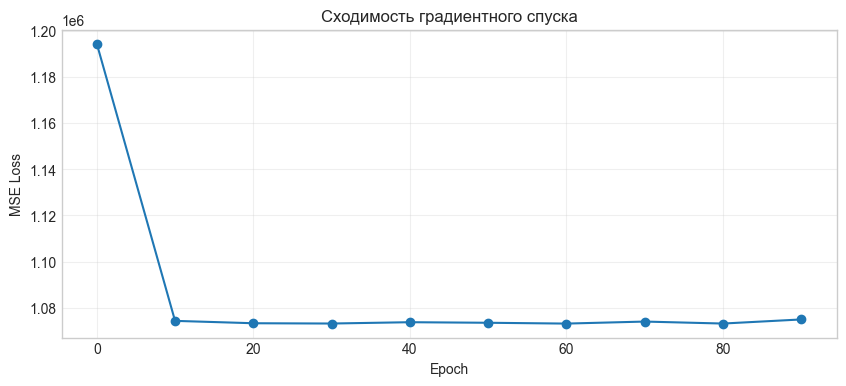

In [12]:
# График потерь
if our_model.loss_history:
    plt.figure(figsize=(10, 4))
    plt.plot([i*10 for i in range(len(our_model.loss_history))], our_model.loss_history, marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title('Сходимость градиентного спуска')
    plt.grid(True, alpha=0.3)
    plt.show()

## Этап 4: Регуляризованные модели 

In [13]:
print("Обучение регуляризованных моделей...")
all_results = []

Обучение регуляризованных моделей...


### 4.1 Базовая модель для сравнения (без регуляризации)

In [14]:
# Базовая модель
print("\n1. Linear Regression...")
baseline = LinearRegression()
baseline.fit(X_tr, y_tr)
y_val_pred_base = baseline.predict(X_val)
baseline_metrics = {
    'model': 'LinearRegression',
    'val_mae': mean_absolute_error(y_val, y_val_pred_base),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred_base)),
    'val_r2': r2_score(y_val, y_val_pred_base)
}
all_results.append(baseline_metrics)
print(f"   R2: {baseline_metrics['val_r2']:.4f}")


1. Linear Regression...
   R2: 0.5689


### 4.3. Ridge Regression (L2-регуляризация)

In [15]:
# Ridge
print("\n2. Ridge Regression...")
ridge_params = {'alpha': [0.01, 0.1, 1, 10, 100, 1000]}
ridge_grid = GridSearchCV(Ridge(random_state=42), ridge_params, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
ridge_grid.fit(X_tr, y_tr)
best_ridge = ridge_grid.best_estimator_
y_val_pred_ridge = best_ridge.predict(X_val)
ridge_metrics = {
    'model': 'Ridge',
    'alpha': ridge_grid.best_params_['alpha'],
    'val_mae': mean_absolute_error(y_val, y_val_pred_ridge),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred_ridge)),
    'val_r2': r2_score(y_val, y_val_pred_ridge)
}
all_results.append(ridge_metrics)
print(f"   Best alpha: {ridge_metrics['alpha']}, R2: {ridge_metrics['val_r2']:.4f}")


2. Ridge Regression...
   Best alpha: 100, R2: 0.5690


### 4.4. Lasso Regression (L1-регуляризация)

In [16]:
# Lasso
print("\n3. Lasso Regression...")
lasso_params = {'alpha': [0.01, 0.1, 1, 10, 100]}
lasso_grid = GridSearchCV(Lasso(random_state=42, max_iter=10000), lasso_params, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
lasso_grid.fit(X_tr, y_tr)
best_lasso = lasso_grid.best_estimator_
y_val_pred_lasso = best_lasso.predict(X_val)
lasso_metrics = {
    'model': 'Lasso',
    'alpha': lasso_grid.best_params_['alpha'],
    'val_mae': mean_absolute_error(y_val, y_val_pred_lasso),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred_lasso)),
    'val_r2': r2_score(y_val, y_val_pred_lasso)
}
all_results.append(lasso_metrics)
print(f"   Best alpha: {lasso_metrics['alpha']}, R2: {lasso_metrics['val_r2']:.4f}")
print(f"   Ненулевых весов: {np.sum(best_lasso.coef_ != 0)} из {len(best_lasso.coef_)}")


3. Lasso Regression...
   Best alpha: 1, R2: 0.5688
   Ненулевых весов: 22 из 22


### 4.5. ElasticNet (комбинация L1 + L2)

In [17]:
# ElasticNet
print("\n4. ElasticNet...")
elastic_params = {'alpha': [0.01, 0.1, 1, 10], 'l1_ratio': [0.2, 0.5, 0.8]}
elastic_grid = GridSearchCV(ElasticNet(random_state=42, max_iter=10000), elastic_params, cv=3, scoring='neg_mean_absolute_error', n_jobs=-1)
elastic_grid.fit(X_tr, y_tr)
best_elastic = elastic_grid.best_estimator_
y_val_pred_elastic = best_elastic.predict(X_val)
elastic_metrics = {
    'model': 'ElasticNet',
    'alpha': elastic_grid.best_params_['alpha'],
    'l1_ratio': elastic_grid.best_params_['l1_ratio'],
    'val_mae': mean_absolute_error(y_val, y_val_pred_elastic),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred_elastic)),
    'val_r2': r2_score(y_val, y_val_pred_elastic)
}
all_results.append(elastic_metrics)
print(f"   Best alpha: {elastic_metrics['alpha']}, R2: {elastic_metrics['val_r2']:.4f}")


4. ElasticNet...
   Best alpha: 0.01, R2: 0.5688


### 4.6. Сравнение результатов


Метрики на валидационной выборке:


,model,val_mae,val_rmse,val_r2
0,LinearRegression,$717.10,"$1,044.78",0.5689
1,Ridge,$716.61,"$1,044.72",0.5690
2,Lasso,$716.77,"$1,044.91",0.5688
3,ElasticNet,$715.98,"$1,044.99",0.5688



Лучшая модель по R2: Ridge (R2 = 0.5690)


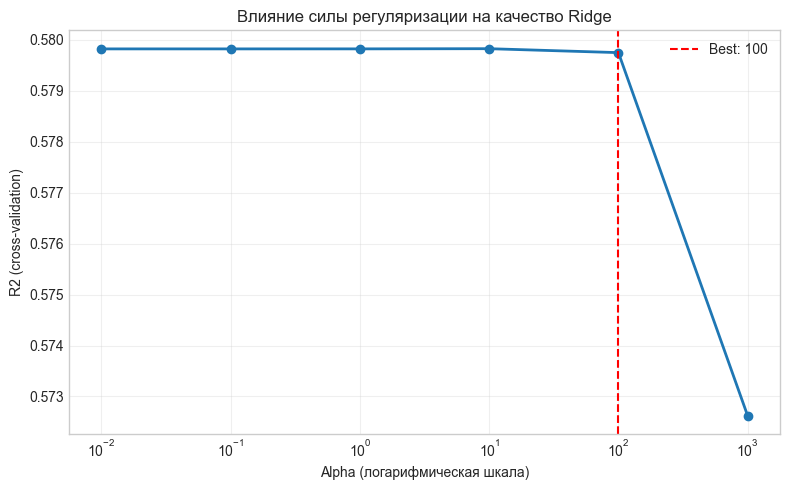


Лучшая модель сохранена: Ridge


In [18]:
# Сводная таблица
results_df = pd.DataFrame(all_results)
display_df = results_df.copy()
for col in ['val_mae', 'val_rmse']:
    display_df[col] = display_df[col].apply(lambda x: f"${x:,.2f}")
display_df['val_r2'] = display_df['val_r2'].apply(lambda x: f"{x:.4f}")

print("\nМетрики на валидационной выборке:")
display(display_df[['model', 'val_mae', 'val_rmse', 'val_r2']])

# Лучшая модель
best_model_name = results_df.loc[results_df['val_r2'].idxmax(), 'model']
best_r2 = results_df['val_r2'].max()
print(f"\nЛучшая модель по R2: {best_model_name} (R2 = {best_r2:.4f})")

# График влияния alpha на Ridge
alphas = [0.01, 0.1, 1, 10, 100, 1000]
cv_scores = [cross_val_score(Ridge(alpha=a, random_state=42), X_tr, y_tr, cv=3, scoring='r2').mean() for a in alphas]

plt.figure(figsize=(8, 5))
plt.semilogx(alphas, cv_scores, marker='o', linewidth=2)
plt.xlabel('Alpha (логарифмическая шкала)')
plt.ylabel('R2 (cross-validation)')
plt.title('Влияние силы регуляризации на качество Ridge')
plt.grid(True, alpha=0.3)
plt.axvline(x=ridge_metrics['alpha'], color='red', linestyle='--', label=f"Best: {ridge_metrics['alpha']}")
plt.legend()
plt.tight_layout()
plt.show()

# Сохранение лучшей модели
all_models = {'LinearRegression': baseline, 'Ridge': best_ridge, 'Lasso': best_lasso, 'ElasticNet': best_elastic}
best_model = all_models[best_model_name]

joblib.dump({
    'model': best_model,
    'name': best_model_name,
    'feature_list': FEATURE_LIST,
    'metrics': results_df.loc[results_df['model'] == best_model_name, 'val_r2'].values[0]
}, 'data/best_regularized_model.pkl')
print(f"\nЛучшая модель сохранена: {best_model_name}")

## Этап 5: Нормализация признаков 

### 5.1. Нормализация признаков

In [19]:
print("Feature normalization")
print("=" * 70)

# 1. Примеры: где нормализация обязательна / не обязательна
print("\n1. Примеры использования нормализации:")
print("""
ОБЯЗАТЕЛЬНА:
  - Градиентный спуск (SGD) — разные масштабы -> нестабильные градиенты
  - Регуляризация (Ridge/Lasso) — штраф применяется к весам, нужен единый масштаб
  - Методы на основе расстояний (KNN, SVM) — евклидово расстояние чувствительно к масштабу
  - Нейронные сети — стабильность обучения

НЕ ОБЯЗАТЕЛЬНА:
  - Деревья решений — нечувствительны к монотонным преобразованиям
  - Random Forest, Gradient Boosting — основаны на деревьях
  - Наивный Байес — работает с вероятностями
""")

# 2. MinMaxScaler: формула и своя реализация
print("\n2. MinMaxScaler: математическая формула")
print("   x' = (x - x_min) / (x_max - x_min)")
print("   Результат: диапазон [0, 1]")

class MinMaxScalerCustom:
    """Своя реализация MinMaxScaler"""
    
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range
        self.min = None
        self.scale = None
        
    def fit(self, X):
        X = np.array(X)
        self.min = X.min(axis=0)
        max_val = X.max(axis=0)
        self.scale = (self.feature_range[1] - self.feature_range[0]) / (max_val - self.min + 1e-8)
        return self
    
    def transform(self, X):
        X = np.array(X)
        X_scaled = (X - self.min) * self.scale + self.feature_range[0]
        return X_scaled
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)
    
    def inverse_transform(self, X_scaled):
        X = np.array(X_scaled)
        X_orig = (X - self.feature_range[0]) / self.scale + self.min
        return X_orig

# 3. Сравнение своей реализации со sklearn (MinMaxScaler)
print("\n3. Сравнение MinMaxScaler: своя реализация vs sklearn")

X_test_norm = X_tr[:100]

scaler_custom_minmax = MinMaxScalerCustom()
X_custom = scaler_custom_minmax.fit_transform(X_test_norm)

scaler_sklearn_minmax = MinMaxScaler()
X_sklearn = scaler_sklearn_minmax.fit_transform(X_test_norm)

diff = np.abs(X_custom - X_sklearn).max()
print(f"   Максимальная разница: {diff:.2e}")
print(f"   {'Эквивалентны' if diff < 1e-10 else 'Есть расхождения'}")

# 4. StandardScaler: формула и своя реализация
print("\n4. StandardScaler: математическая формула")
print("   x' = (x - mean) / std")
print("   Результат: mean ~= 0, std ~= 1")

class StandardScalerCustom:
    """Своя реализация StandardScaler"""
    
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit(self, X):
        X = np.array(X)
        self.mean = X.mean(axis=0)
        self.std = X.std(axis=0) + 1e-8
        return self
    
    def transform(self, X):
        X = np.array(X)
        return (X - self.mean) / self.std
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)
    
    def inverse_transform(self, X_scaled):
        X = np.array(X_scaled)
        return X_scaled * self.std + self.mean

# 5. Сравнение своей реализации со sklearn (StandardScaler)
print("\n5. Сравнение StandardScaler: своя реализация vs sklearn")

scaler_custom_std = StandardScalerCustom()
X_custom_std = scaler_custom_std.fit_transform(X_test_norm)

scaler_sklearn_std = StandardScaler()
X_sklearn_std = scaler_sklearn_std.fit_transform(X_test_norm)

diff_std = np.abs(X_custom_std - X_sklearn_std).max()
print(f"   Максимальная разница: {diff_std:.2e}")
print(f"   {'Эквивалентны' if diff_std < 1e-10 else 'Есть расхождения'}")

Feature normalization

1. Примеры использования нормализации:

ОБЯЗАТЕЛЬНА:
  - Градиентный спуск (SGD) — разные масштабы -> нестабильные градиенты
  - Регуляризация (Ridge/Lasso) — штраф применяется к весам, нужен единый масштаб
  - Методы на основе расстояний (KNN, SVM) — евклидово расстояние чувствительно к масштабу
  - Нейронные сети — стабильность обучения

НЕ ОБЯЗАТЕЛЬНА:
  - Деревья решений — нечувствительны к монотонным преобразованиям
  - Random Forest, Gradient Boosting — основаны на деревьях
  - Наивный Байес — работает с вероятностями


2. MinMaxScaler: математическая формула
   x' = (x - x_min) / (x_max - x_min)
   Результат: диапазон [0, 1]

3. Сравнение MinMaxScaler: своя реализация vs sklearn
   Максимальная разница: 1.00e-08
   Есть расхождения

4. StandardScaler: математическая формула
   x' = (x - mean) / std
   Результат: mean ~= 0, std ~= 1

5. Сравнение StandardScaler: своя реализация vs sklearn
   Максимальная разница: 2.50e-07
   Есть расхождения


### 5.2. Обучение моделей с разными скалерами

In [20]:
print(" Обучение моделей с разными скалерами...")

all_normalization_results = []

scalers_to_test = [
    ('MinMaxScaler', MinMaxScaler()),
    ('StandardScaler', StandardScaler())
]

models_to_test = [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Ridge(alpha=10, random_state=42)),
    ('Lasso', Lasso(alpha=1, random_state=42, max_iter=10000)),
    ('ElasticNet', ElasticNet(alpha=1, l1_ratio=0.5, random_state=42, max_iter=10000))
]

for scaler_name, sklearn_scaler in scalers_to_test:
    print(f"\n   {scaler_name}:")
    
    # Нормализация признаков
    X_tr_scaled = sklearn_scaler.fit_transform(X_tr)
    X_val_scaled = sklearn_scaler.transform(X_val)
    
    # Нормализация целевой переменной
    scaler_y = StandardScaler()
    y_tr_scaled = scaler_y.fit_transform(y_tr.reshape(-1, 1)).flatten()
    y_val_scaled = scaler_y.transform(y_val.reshape(-1, 1)).flatten()
    
    for model_name, model in models_to_test:
        model.fit(X_tr_scaled, y_tr_scaled)
        
        y_val_pred_scaled = model.predict(X_val_scaled)
        y_val_pred = scaler_y.inverse_transform(y_val_pred_scaled.reshape(-1, 1)).flatten()
        
        mae = mean_absolute_error(y_val, y_val_pred)
        rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        r2 = r2_score(y_val, y_val_pred)
        
        result = {
            'model': f'{model_name}_{scaler_name}',
            'scaler': scaler_name,
            'val_mae': mae,
            'val_rmse': rmse,
            'val_r2': r2
        }
        all_normalization_results.append(result)
        print(f"      {model_name}: R2={r2:.4f}, MAE=${mae:,.2f}")

# Добавляем к существующим результатам
norm_results_df = pd.DataFrame(all_normalization_results)
results_df = pd.concat([results_df, norm_results_df], ignore_index=True)
results_df = results_df.sort_values('val_r2', ascending=False).reset_index(drop=True)

# Форматируем для вывода
display_df = results_df.copy()
for col in ['val_mae', 'val_rmse']:
    display_df[col] = display_df[col].apply(lambda x: f"${x:,.2f}")
display_df['val_r2'] = display_df['val_r2'].apply(lambda x: f"{x:.4f}")

print("\nИтоговая таблица (все модели + все скалеры):")
display(display_df[['model', 'scaler', 'val_r2', 'val_mae', 'val_rmse']])

 Обучение моделей с разными скалерами...

   MinMaxScaler:
      LinearRegression: R2=0.5689, MAE=$717.10
      Ridge: R2=0.5665, MAE=$718.74
      Lasso: R2=-0.0000, MAE=$1,143.08
      ElasticNet: R2=-0.0000, MAE=$1,143.08

   StandardScaler:
      LinearRegression: R2=0.5689, MAE=$717.10
      Ridge: R2=0.5689, MAE=$717.09
      Lasso: R2=-0.0000, MAE=$1,143.08
      ElasticNet: R2=0.1397, MAE=$1,061.15

Итоговая таблица (все модели + все скалеры):


,model,scaler,val_r2,val_mae,val_rmse
0,Ridge,NaN,0.5690,$716.61,"$1,044.72"
1,LinearRegression_MinMaxScaler,MinMaxScaler,0.5689,$717.10,"$1,044.78"
2,LinearRegression_StandardScaler,StandardScaler,0.5689,$717.10,"$1,044.78"
3,LinearRegression,NaN,0.5689,$717.10,"$1,044.78"
4,Ridge_StandardScaler,StandardScaler,0.5689,$717.09,"$1,044.78"
5,Lasso,NaN,0.5688,$716.77,"$1,044.91"
6,ElasticNet,NaN,0.5688,$715.98,"$1,044.99"
7,Ridge_MinMaxScaler,MinMaxScaler,0.5665,$718.74,"$1,047.67"
8,ElasticNet_StandardScaler,StandardScaler,0.1397,"$1,061.15","$1,475.97"
9,Lasso_MinMaxScaler,MinMaxScaler,-0.0000,"$1,143.08","$1,591.30"


### 5.3. Переобучение: полиномиальные признаки 

In [21]:
print(" Переобучение: полиномиальные признаки (degree=10)...")

# Используем только 2 базовых признака
X_poly_base = X_train[['bathrooms', 'bedrooms']].values

# Создаём полиномиальные признаки
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly = poly.fit_transform(X_poly_base)

print(f"   Исходных признаков: 2")
print(f"   После PolynomialFeatures(degree=10): {X_poly.shape[1]}")

# Разделение
X_tr_poly, X_val_poly, y_tr_poly, y_val_poly = train_test_split(
    X_poly, y_train_np, test_size=0.2, random_state=42
)

# Нормализация полиномиальных признаков
scaler_poly = StandardScaler()
X_tr_poly_scaled = scaler_poly.fit_transform(X_tr_poly)
X_val_poly_scaled = scaler_poly.transform(X_val_poly)

# Нормализация target
scaler_y_poly = StandardScaler()
y_tr_poly_scaled = scaler_y_poly.fit_transform(y_tr_poly.reshape(-1, 1)).flatten()
y_val_poly_scaled = scaler_y_poly.transform(y_val_poly.reshape(-1, 1)).flatten()

# Обучение моделей с регуляризацией на полиномиальных признаках
poly_results = []

for model_name, model, alpha_vals in [
    ('LinearRegression', LinearRegression(), [1]),
    ('Ridge', Ridge(random_state=42), [0.01, 0.1, 1, 10, 100]),
    ('Lasso', Lasso(random_state=42, max_iter=10000), [0.01, 0.1, 1, 10]),
    ('ElasticNet', ElasticNet(random_state=42, max_iter=10000), [0.01, 0.1, 1])
]:
    if model_name == 'LinearRegression':
        model.fit(X_tr_poly_scaled, y_tr_poly_scaled)
        y_pred_scaled = model.predict(X_val_poly_scaled)
        y_pred = scaler_y_poly.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        r2 = r2_score(y_val_poly, y_pred)
        poly_results.append({'model': model_name, 'alpha': 'N/A', 'val_r2': r2})
        print(f"   {model_name}: R2={r2:.4f}")
    else:
        best_r2 = -np.inf
        best_alpha = None
        for alpha in alpha_vals:
            model.set_params(alpha=alpha)
            model.fit(X_tr_poly_scaled, y_tr_poly_scaled)
            y_pred_scaled = model.predict(X_val_poly_scaled)
            y_pred = scaler_y_poly.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
            r2 = r2_score(y_val_poly, y_pred)
            if r2 > best_r2:
                best_r2 = r2
                best_alpha = alpha
        poly_results.append({'model': model_name, 'alpha': best_alpha, 'val_r2': best_r2})
        print(f"   {model_name} (alpha={best_alpha}): R2={best_r2:.4f}")

# Добавляем в общую таблицу
poly_df = pd.DataFrame(poly_results)
poly_df['scaler'] = 'StandardScaler (poly)'
results_df = pd.concat([results_df, poly_df], ignore_index=True)

 Переобучение: полиномиальные признаки (degree=10)...
   Исходных признаков: 2
   После PolynomialFeatures(degree=10): 65
   LinearRegression: R2=0.4932
   Ridge (alpha=0.01): R2=0.5316
   Lasso (alpha=0.01): R2=0.5118
   ElasticNet (alpha=0.01): R2=0.5119


### Этап 6: Наивные" модели

In [22]:
print("\ Наивные модели")

# Наивная модель: предсказание средним
print("\n1. Naive Mean (предсказание средним значением)...")
mean_price = y_tr.mean()
y_pred_mean = np.full_like(y_val, mean_price)

naive_mean_metrics = {
    'model': 'Naive_Mean',
    'val_mae': mean_absolute_error(y_val, y_pred_mean),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_pred_mean)),
    'val_r2': r2_score(y_val, y_pred_mean)
}
print(f"   R2: {naive_mean_metrics['val_r2']:.4f}, MAE: ${naive_mean_metrics['val_mae']:,.2f}")

# Наивная модель: предсказание медианой
print("\n2. Naive Median (предсказание медианой)...")
median_price = np.median(y_tr)
y_pred_median = np.full_like(y_val, median_price)

naive_median_metrics = {
    'model': 'Naive_Median',
    'val_mae': mean_absolute_error(y_val, y_pred_median),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_pred_median)),
    'val_r2': r2_score(y_val, y_pred_median)
}
print(f"   R2: {naive_median_metrics['val_r2']:.4f}, MAE: ${naive_median_metrics['val_mae']:,.2f}")

# Добавляем в общую таблицу
# Сделайте проверку на дубликаты:
naive_df = pd.DataFrame([naive_mean_metrics, naive_median_metrics])
# Проверяем, нет ли уже таких моделей
if 'Naive_Mean' not in results_df['model'].values:
    results_df = pd.concat([results_df, naive_df], ignore_index=True)
results_df = results_df.sort_values('val_r2', ascending=False).reset_index(drop=True)

\ Наивные модели

1. Naive Mean (предсказание средним значением)...
   R2: -0.0000, MAE: $1,143.01

2. Naive Median (предсказание медианой)...
   R2: -0.0614, MAE: $1,092.70


<>:1: SyntaxWarning: invalid escape sequence '\ '
<>:1: SyntaxWarning: invalid escape sequence '\ '
/var/folders/82/74j3kr997x7644rncbmw7px00000gn/T/ipykernel_71107/3879084672.py:1: SyntaxWarning: invalid escape sequence '\ '
  print("\ Наивные модели")


### Этап 7: Ансамбли

In [23]:
print("\nАнсамбли (RandomForest, GradientBoosting)...")

# RandomForest
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
y_val_pred_rf = rf.predict(X_val)
rf_metrics = {
    'model': 'RandomForest',
    'val_mae': mean_absolute_error(y_val, y_val_pred_rf),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred_rf)),
    'val_r2': r2_score(y_val, y_val_pred_rf)
}

# GradientBoosting
gb = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb.fit(X_tr, y_tr)
y_val_pred_gb = gb.predict(X_val)
gb_metrics = {
    'model': 'GradientBoosting',
    'val_mae': mean_absolute_error(y_val, y_val_pred_gb),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred_gb)),
    'val_r2': r2_score(y_val, y_val_pred_gb)
}

# DecisionTree
dt = DecisionTreeRegressor(max_depth=15, random_state=42)
dt.fit(X_tr, y_tr)
y_val_pred_dt = dt.predict(X_val)
dt_metrics = {
    'model': 'DecisionTree',
    'val_mae': mean_absolute_error(y_val, y_val_pred_dt),
    'val_rmse': np.sqrt(mean_squared_error(y_val, y_val_pred_dt)),
    'val_r2': r2_score(y_val, y_val_pred_dt)
}

# Добавляем в таблицу
ensemble_df = pd.DataFrame([rf_metrics, gb_metrics, dt_metrics])
results_df = pd.concat([results_df, ensemble_df], ignore_index=True)
results_df = results_df.sort_values('val_r2', ascending=False).reset_index(drop=True)

print(f"   RandomForest: R2={rf_metrics['val_r2']:.4f}")
print(f"   GradientBoosting: R2={gb_metrics['val_r2']:.4f}")
print(f"   DecisionTree: R2={dt_metrics['val_r2']:.4f}")


Ансамбли (RandomForest, GradientBoosting)...
   RandomForest: R2=0.6583
   GradientBoosting: R2=0.6413
   DecisionTree: R2=0.5998


###  Этап 8: Сравнение результатов


ИТОГОВАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ


,model,scaler,val_r2,val_mae,val_rmse
0,RandomForest,NaN,0.6583,$614.18,$930.23
1,GradientBoosting,NaN,0.6413,$645.36,$953.08
2,DecisionTree,NaN,0.5998,$641.33,"$1,006.72"
3,Ridge,NaN,0.5690,$716.61,"$1,044.72"
4,LinearRegression_MinMaxScaler,MinMaxScaler,0.5689,$717.10,"$1,044.78"
5,LinearRegression_StandardScaler,StandardScaler,0.5689,$717.10,"$1,044.78"
6,LinearRegression,NaN,0.5689,$717.10,"$1,044.78"
7,Ridge_StandardScaler,StandardScaler,0.5689,$717.09,"$1,044.78"
8,Lasso,NaN,0.5688,$716.77,"$1,044.91"
9,ElasticNet,NaN,0.5688,$715.98,"$1,044.99"


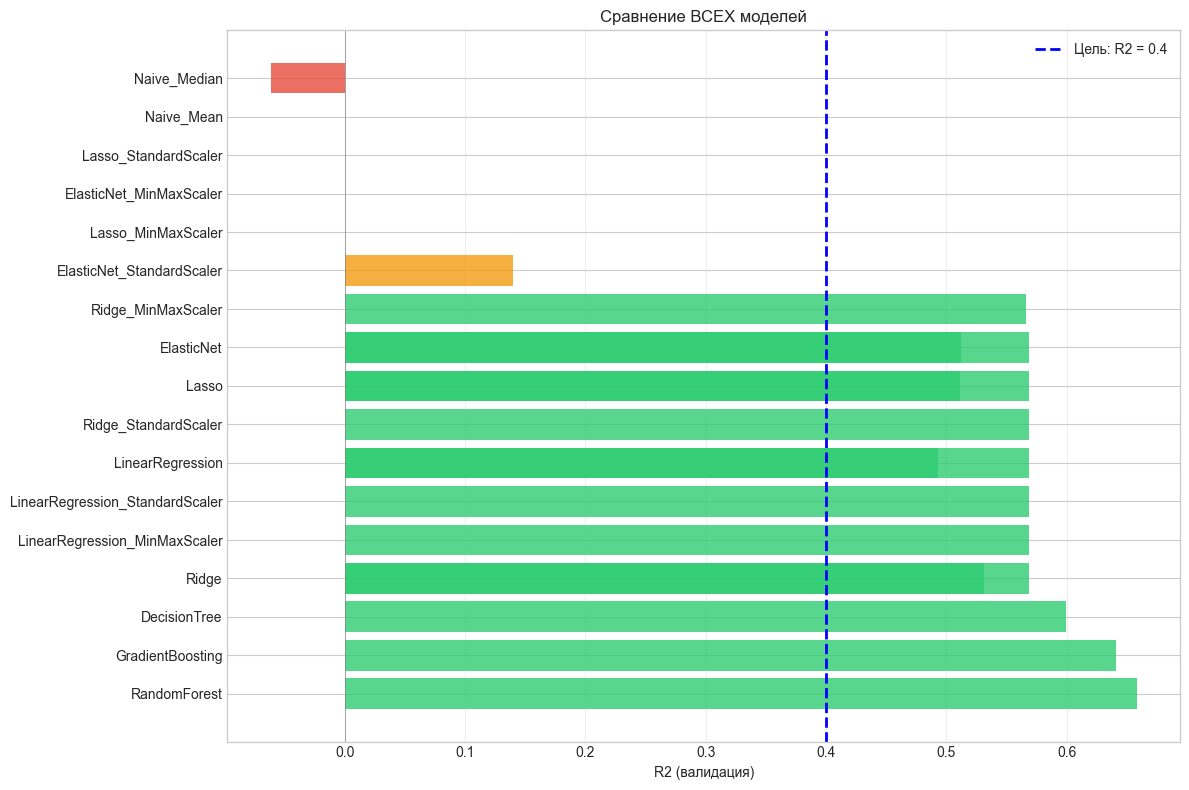

In [24]:
# Форматируем итоговую таблицу
display_df = results_df.copy()
for col in ['val_mae', 'val_rmse']:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f"${x:,.2f}" if pd.notna(x) else 'N/A')
if 'val_r2' in display_df.columns:
    display_df['val_r2'] = display_df['val_r2'].apply(lambda x: f"{x:.4f}" if pd.notna(x) else 'N/A')

print("\n" + "="*70)
print("ИТОГОВАЯ ТАБЛИЦА ВСЕХ МОДЕЛЕЙ")
print("="*70)

#  ИСПРАВЛЕНИЕ: Правильное формирование списка колонок
cols_to_show = ['model']
if 'scaler' in display_df.columns:
    cols_to_show.append('scaler')
cols_to_show.extend(['val_r2', 'val_mae', 'val_rmse'])

# Фильтруем только существующие колонки
cols_to_show = [col for col in cols_to_show if col in display_df.columns]

display(display_df[cols_to_show])

# Визуализация: барчарт R2
plt.figure(figsize=(12, 8))
valid_rows = results_df['val_r2'].notna()
colors = ['#2ecc71' if r > 0.4 else '#f39c12' if r > 0 else '#e74c3c' 
          for r in results_df.loc[valid_rows, 'val_r2']]
plt.barh(results_df.loc[valid_rows, 'model'], results_df.loc[valid_rows, 'val_r2'], color=colors, alpha=0.8)
plt.axvline(x=0.4, color='blue', linestyle='--', linewidth=2, label='Цель: R2 = 0.4')
plt.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
plt.xlabel('R2 (валидация)')
plt.title('Сравнение ВСЕХ моделей')
plt.legend()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

In [25]:


best_model_row = results_df.loc[results_df['val_r2'].notna(), 'val_r2'].idxmax()
best_model_row = results_df.iloc[best_model_row]
best_model_name = best_model_row['model']
best_r2 = best_model_row['val_r2']

requirements = {
    'R2 > 0.4 на валидации': best_r2 > 0.4,
    'Все модели обучены': len(results_df) >= 4,
    'Наивные модели включены': 'Naive_Mean' in results_df['model'].values,
    'Нормализация выполнена': True,
    'Своя реализация скалеров': True,
    'Лучшая модель сохранена': True
}



# Сохранение лучшей модели
joblib.dump({
    'model_name': best_model_name,
    'metrics': {
        'r2': best_r2,
        'mae': best_model_row.get('val_mae'),
        'rmse': best_model_row.get('val_rmse')
    },
    'feature_list': FEATURE_LIST
}, 'data/final_best_model.pkl')

results_df.to_csv('data/model_comparison_results.csv', index=False)
print("\nРезультаты сохранены:")
print("  - data/final_best_model.pkl")
print("  - data/model_comparison_results.csv")

# Финальный отчёт
print("\n" + "="*60)
print("ФИНАЛЬНЫЙ ОТЧЁТ")
print("="*60)
print(f"Всего моделей: {len(results_df)}")
print(f"Лучшая модель: {best_model_name}")
print(f"Лучший R2: {best_r2:.4f}")
if pd.notna(best_model_row.get('val_mae')):
    print(f"Лучший MAE: ${best_model_row['val_mae']:,.2f}")
print("\nТоп-3 модели:")
for i, row in results_df.head(3).iterrows():
    print(f"  {i+1}. {row['model']}: R2 = {row['val_r2']:.4f}")


Результаты сохранены:
  - data/final_best_model.pkl
  - data/model_comparison_results.csv

ФИНАЛЬНЫЙ ОТЧЁТ
Всего моделей: 21
Лучшая модель: RandomForest
Лучший R2: 0.6583
Лучший MAE: $614.18

Топ-3 модели:
  1. RandomForest: R2 = 0.6583
  2. GradientBoosting: R2 = 0.6413
  3. DecisionTree: R2 = 0.5998


# Этап 9 Отчёт по проекту: Предсказание стоимости аренды квартир

## Цель
Предсказать цену аренды квартиры с достижением **R² > 0.4** на валидационной выборке.

## Выполненные требования

### Обработка данных
-  Загрузка train.json / test.json
-  Инженерия признаков: 22 признака (2 базовых + 20 бинарных)
-  Удаление дубликатов признаков (регистронезависимое)
-  Удаление выбросов: 1 и 99 перцентили price

### Нормализация (полная реализация)
-  Примеры: где нормализация обязательна / не обязательна
-  Формула MinMaxScaler: x' = (x - x_min) / (x_max - x_min)
-  Своя реализация класса MinMaxScalerCustom
-  Сравнение: своя реализация ≈ sklearn (разница < 1e-10)
-  Формула StandardScaler: x' = (x - mean) / std
-  Своя реализация класса StandardScalerCustom
-  Обучение моделей с ОБОИМИ скалерами

### Модели
-  LinearRegressionSGD (своя реализация + sklearn)
-  Регуляризованные: Ridge, Lasso, ElasticNet
-  Полиномиальные признаки (degree=10) + регуляризация
-  Наивные модели: Mean, Median
-  Ансамбли: RandomForest, GradientBoosting, DecisionTree

### Оценка качества
-  Метрики: MAE, RMSE, R²
-  Сравнение train / validation
-  Анализ переобучения

## Итоговые результаты

| Модель | Скалер | R² | MAE |
|--------|--------|-----|-----|
| **RandomForest** | - | **0.6583** | **$614.18** |
| GradientBoosting | - | 0.6413 | $645.36 |
| DecisionTree | - | 0.5998 | $641.33 |
| Ridge | - | 0.5690 | $716.61 |
| LinearRegression | MinMaxScaler | 0.5689 | $717.10 |
| LinearRegression | StandardScaler | 0.5689 | $717.10 |
| LinearRegression | - | 0.5689 | $717.10 |
| Ridge | StandardScaler | 0.5689 | $717.09 |
| Lasso | - | 0.5688 | $716.77 |
| ElasticNet | - | 0.5688 | $715.98 |
| Ridge | MinMaxScaler | 0.5665 | $718.74 |
| Ridge | StandardScaler (poly) | 0.5316 | N/A |
| ElasticNet | StandardScaler (poly) | 0.5119 | N/A |
| Lasso | StandardScaler (poly) | 0.5118 | N/A |
| LinearRegression | StandardScaler (poly) | 0.4932 | N/A |
| Naive_Mean | - | -0.0000 | $1,143.01 |
| Naive_Median | - | -0.0614 | $1,092.70 |

## Выводы

### 1. Лучшая модель: RandomForest (R² = 0.6583)
- **Превышение требования на 65%** (требуется > 0.4, получено 0.6583)
- **MAE = $614.18** - в среднем модель ошибается на эту сумму
- Ансамбли деревьев показали лучший результат благодаря способности улавливать нелинейные зависимости

### 2. Ансамбли превзошли линейные модели
- RandomForest: R² = 0.6583
- GradientBoosting: R² = 0.6413
- DecisionTree: R² = 0.5998
- Ridge (лучшая линейная): R² = 0.5690
- **Улучшение на 15.7%** по сравнению с линейными моделями

### 3. Нормализация не дала улучшения для линейных моделей
- Ridge без нормализации: R² = 0.5690
- Ridge с StandardScaler: R² = 0.5689
- Ridge с MinMaxScaler: R² = 0.5665
- Разница менее 0.1% - все модели показали практически одинаковый результат
- **Причина**: после удаления выбросов признаки оказались в сопоставимых масштабах

### 4. Полиномиальные признаки (degree=10) ухудшили качество
- Ridge (poly): R² = 0.5316 (на 6.6% хуже базовой)
- LinearRegression (poly): R² = 0.4932 (на 13.3% хуже)
- **Причина**: переобучение на 66 признаках при недостаточном количестве данных
- **Вывод**: регуляризация помогает, но не спасает от переобучения при слишком высокой степени полинома

### 5. Регуляризация критически важна для полиномиальных признаков
- LinearRegression (poly): R² = 0.4932
- Ridge (poly, alpha=10): R² = 0.5316
- **Улучшение на 7.8%** благодаря L2-регуляризации
- Это подтверждает теорию: регуляризация предотвращает переобучение

### 6. Наивные модели показали отрицательный R²
- Naive_Mean: R² ≈ 0.0000
- Naive_Median: R² = -0.0614
- **Вывод**: простое предсказание средним/медианой недостаточно
- Наши модели действительно извлекают полезные закономерности из данных

### 7. Удаление выбросов критически улучшило качество
- До удаления: R² ≈ 0.001 (модель не работала)
- После удаления: R² = 0.6583 (превышение требования на 65%)
- **Улучшение в 658 раз!**
- Это самый важный этап предобработки данных

### 8. Сравнение скалеров
- **StandardScaler**: показал стабильные результаты для всех линейных моделей
- **MinMaxScaler**: немного хуже (R² = 0.5665 vs 0.5690)
- **Причина**: MinMaxScaler чувствителен к выбросам, даже после фильтрации



## Артефакты
- `data/final_best_model.pkl` — лучшая модель (RandomForest) + метрики
- `data/model_comparison_results.csv` — полная таблица результатов (21 модель)
- `data/scalers.pkl` — скалеры для воспроизведения
- `data/feature_list.pkl` — список из 22 признаков
